# Imports


In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests


from model import *
import random
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from model.initialization import init_blocks_spectral, init_spectral_with_z
from helper_functions import *

from helper_functions.Estimate_p import estimate_p_multicluster, match_clusters

DATA_DIR       = Path("f1_data")
RAW_DIR        = DATA_DIR / "raw"
RANKINGS_DIR   = DATA_DIR / "rankings"
MATRICES_DIR   = DATA_DIR / "matrices"
PER_SEASON_DIR = MATRICES_DIR / "per_season"


# Download data

In [2]:
"""
Formula 1 Race Results → Strict Complete Rankings
---------------------------------------------------
Downloads F1 race finishing positions from the Jolpica API
(api.jolpi.ca — the open-source successor to the Ergast API)
and converts each race into a strict complete ranking of drivers.

Each race naturally produces one strict complete ranking:
    assessor  = one race
    items     = drivers
    rank      = finishing position (1 = winner)

This is exactly the data format needed for Mallows mixture models.
DNFs (did-not-finish) are handled explicitly — see options below.

Dependencies: pip install requests pandas numpy

Output folder structure:
    f1_data/
        raw/            ← raw API results
        rankings/       ← long-format rankings
        matrices/       ← rank matrices (all seasons)
            per_season/ ← one matrix per season
"""

# ──────────────────────────────────────────────
# Output directories
# ──────────────────────────────────────────────




# ──────────────────────────────────────────────
# 1.  Jolpica API helpers
# ──────────────────────────────────────────────

BASE_URL = "https://api.jolpi.ca/ergast/f1"
PAUSE    = 1.0   # seconds between requests — be a polite API user


def _get(url: str, params: dict | None = None, max_retries: int = 5) -> dict:
    """GET with exponential backoff on 429 Too Many Requests."""
    for attempt in range(max_retries):
        resp = requests.get(url, params=params, timeout=30)
        if resp.status_code == 429:
            wait = 2 ** attempt  # 1, 2, 4, 8, 16 seconds
            print(f"\n  Rate limited (429). Waiting {wait}s before retry {attempt + 1}/{max_retries}...")
            time.sleep(wait)
            continue
        resp.raise_for_status()
        time.sleep(PAUSE)
        return resp.json()
    raise requests.HTTPError(f"Still getting 429 after {max_retries} retries: {url}")


def get_race_results(season: int, round_: int) -> list[dict]:
    """
    Fetch finishing results for one race.
    Returns a list of result dicts from the Jolpica API.
    """
    url  = f"{BASE_URL}/{season}/{round_}/results.json"
    data = _get(url, params={"limit": 30})
    races = data["MRData"]["RaceTable"]["Races"]
    if not races:
        return []
    return races[0]["Results"]


def get_season_schedule(season: int) -> list[dict]:
    """Return the list of races (with round numbers) for a season."""
    url  = f"{BASE_URL}/{season}.json"
    data = _get(url, params={"limit": 30})
    return data["MRData"]["RaceTable"]["Races"]


# ──────────────────────────────────────────────
# 2.  Download one full season
# ──────────────────────────────────────────────

def download_season(season: int) -> pd.DataFrame:
    """
    Download all race results for a season and return a flat DataFrame.

    Columns:
        season, round, race_name, date, circuit,
        driver_id, driver_code, driver_name,
        constructor, grid_position, finish_position,
        points, status, laps
    """
    schedule = get_season_schedule(season)
    n_rounds = len(schedule)
    rows = []

    for race in schedule:
        rnd       = int(race["round"])
        race_name = race["raceName"]
        date      = race.get("date", "")
        circuit   = race["Circuit"]["circuitName"]

        print(f"  {season} Round {rnd:2d}/{n_rounds}  {race_name}...", end=" ")
        results = get_race_results(season, rnd)

        if not results:
            print("no data")
            continue

        for r in results:
            driver = r["Driver"]
            rows.append({
                "season":          season,
                "round":           rnd,
                "race_name":       race_name,
                "date":            date,
                "circuit":         circuit,
                "driver_id":       driver["driverId"],
                "driver_code":     driver.get("code", ""),
                "driver_name":     f"{driver['givenName']} {driver['familyName']}",
                "constructor":     r["Constructor"]["name"],
                "grid_position":   int(r.get("grid", 0)),
                "finish_position": int(r["position"]) if r["positionText"].isdigit() else None,
                "points":          float(r.get("points", 0)),
                "status":          r.get("status", ""),
                "laps":            int(r.get("laps", 0)),
            })

        n_classified = sum(1 for r in results if r["positionText"].isdigit())
        print(f"{n_classified} classified")

    return pd.DataFrame(rows)


def download_multiple_seasons(
    start: int = 1950,
    end:   int = 2023,
) -> pd.DataFrame:
    """Download and concatenate results for a range of seasons."""
    frames = []
    for season in range(start, end + 1):
        print(f"\n── Season {season} ──────────────────────────")
        df = download_season(season)
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


# ──────────────────────────────────────────────
# 3.  Convert to strict rankings
# ──────────────────────────────────────────────

def races_to_rankings(
    results: pd.DataFrame,
    dnf_strategy: str = "last",
    min_drivers:  int = 10,
) -> pd.DataFrame:
    """
    Convert raw race results to a strict ranking per race.

    Parameters
    ----------
    results      : raw DataFrame from download_season / download_multiple_seasons
    dnf_strategy : how to handle DNFs (Did Not Finish):
        'drop'    — exclude DNF drivers entirely; race may have fewer items
        'last'    — assign DNFs the lowest ranks (after finishers),
                    ordered by laps completed (more laps = better rank)
        'exclude' — exclude any race containing a DNF entirely
    min_drivers  : minimum classified drivers for a race to be kept

    Returns
    -------
    DataFrame with columns [season, round, race_name, date, circuit,
                             driver_id, driver_code, driver_name, rank]
    One row per driver per race, rank = 1 (winner) to N.
    """
    if dnf_strategy not in ("drop", "last", "exclude"):
        raise ValueError("dnf_strategy must be 'drop', 'last', or 'exclude'")

    records = []

    for (season, rnd), grp in results.groupby(["season", "round"]):
        meta = grp.iloc[0]

        finishers = grp[grp["finish_position"].notna()].copy()
        dnfs      = grp[grp["finish_position"].isna()].copy()

        if dnf_strategy == "exclude" and len(dnfs) > 0:
            continue  # skip any race with a DNF

        if dnf_strategy == "drop":
            ranked = finishers.sort_values("finish_position")
            ranked["rank"] = np.arange(1, len(ranked) + 1)

        else:  # 'last' — finishers first, then DNFs ordered by laps
            finishers = finishers.sort_values("finish_position")
            finishers["rank"] = np.arange(1, len(finishers) + 1)

            if len(dnfs) > 0:
                # More laps completed → ranked higher among DNFs
                dnfs = dnfs.sort_values("laps", ascending=False)
                dnfs["rank"] = np.arange(
                    len(finishers) + 1,
                    len(finishers) + len(dnfs) + 1
                )
                ranked = pd.concat([finishers, dnfs])
            else:
                ranked = finishers

        if len(ranked) < min_drivers:
            continue

        for _, row in ranked.iterrows():
            records.append({
                "season":      row["season"],
                "round":       row["round"],
                "race_name":   meta["race_name"],
                "date":        meta["date"],
                "circuit":     meta["circuit"],
                "driver_id":   row["driver_id"],
                "driver_code": row["driver_code"],
                "driver_name": row["driver_name"],
                "rank":        int(row["rank"]),
            })

    return pd.DataFrame(records).sort_values(["season", "round", "rank"]).reset_index(drop=True)


# ──────────────────────────────────────────────
# 4.  Build rank matrix for Mallows models
# ──────────────────────────────────────────────

def to_rank_matrix(
    rankings: pd.DataFrame,
    common_drivers_only: bool = True,
) -> tuple[np.ndarray, list[str], list[str]]:
    """
    Pivot to a matrix of shape (n_races × n_drivers).

    Entry [i, j] = rank of driver j in race i.

    Parameters
    ----------
    rankings             : output of races_to_rankings()
    common_drivers_only  : if True, keep only drivers who appear
                           in ALL races (guarantees complete matrix).
                           If False, missing values are filled with
                           the worst rank + 1 (absent = last).

    Returns
    -------
    matrix   : np.ndarray  shape (n_races, n_drivers)
    races    : list of "{season} R{round} {race_name}" labels
    drivers  : list of driver_id strings
    """
    rankings = rankings.copy()
    rankings["race_label"] = (
        rankings["season"].astype(str)
        + " R" + rankings["round"].astype(str).str.zfill(2)
        + " " + rankings["race_name"]
    )

    pivot = rankings.pivot_table(
        index="race_label",
        columns="driver_id",
        values="rank",
        aggfunc="first",
    )

    if common_drivers_only:
        present_in_all = pivot.notna().all(axis=0)
        n_dropped = (~present_in_all).sum()
        if n_dropped:
            print(f"  Dropping {n_dropped} drivers not in all races "
                  f"({present_in_all.sum()} remain).")
        pivot = pivot.loc[:, present_in_all]
    else:
        worst = pivot.max(axis=1)
        pivot = pivot.apply(lambda col: col.fillna(worst + 1))

    matrix  = pivot.values.astype(int)
    races   = list(pivot.index)
    drivers = list(pivot.columns)

    return matrix, races, drivers


# ──────────────────────────────────────────────
# 5.  Quick summary
# ──────────────────────────────────────────────

def summarise(results: pd.DataFrame, rankings: pd.DataFrame) -> None:
    print("\n── Raw Results ──────────────────────────────────")
    print(f"  Seasons : {results['season'].min()} – {results['season'].max()}")
    print(f"  Races   : {results.groupby(['season','round']).ngroups}")
    print(f"  Drivers : {results['driver_id'].nunique()}")
    dnf_pct = results["finish_position"].isna().mean() * 100
    print(f"  DNF rate: {dnf_pct:.1f}%")

    print("\n── Rankings ─────────────────────────────────────")
    n_races = rankings.groupby(["season", "round"]).ngroups
    print(f"  Races kept  : {n_races}")
    print(f"  Drivers/race: {rankings.groupby(['season','round'])['driver_id'].count().describe()[['min','mean','max']].round(1).to_dict()}")
    print("─────────────────────────────────────────────────\n")


# ──────────────────────────────────────────────
# 6.  Main — example usage
# ──────────────────────────────────────────────

if __name__ == "__main__":

    print("Downloading F1 race results from Jolpica API...")
    results = download_multiple_seasons(start=2010, end=2023)

    out = RAW_DIR / "f1_results_raw.csv"
    results.to_csv(out, index=False)
    print(f"\nSaved: {out}")

    rankings = races_to_rankings(results, dnf_strategy="last", min_drivers=15)
    summarise(results, rankings)

    example = rankings[(rankings["season"] == 2021) & (rankings["round"] == 1)]
    print("Example: 2021 Round 1 rankings")
    print(example[["rank", "driver_code", "driver_name"]].to_string(index=False))

    out = RANKINGS_DIR / "f1_rankings.csv"
    rankings.to_csv(out, index=False)
    print(f"\nSaved: {out}")

    print("\nBuilding rank matrix (common drivers across all races)...")
    matrix, races, drivers = to_rank_matrix(rankings, common_drivers_only=True)
    print(f"  Matrix shape: {matrix.shape}  (races × drivers)")

    out = MATRICES_DIR / "f1_rank_matrix.csv"
    pd.DataFrame(matrix, index=races, columns=drivers).to_csv(out)
    print(f"Saved: {out}")

    print("\nBuilding per-season rank matrices...")
    for season in sorted(rankings["season"].unique()):
        season_rankings = rankings[rankings["season"] == season]
        mat, race_labels, driver_ids = to_rank_matrix(season_rankings, common_drivers_only=True)
        print(f"  {season}: {mat.shape[0]} races × {mat.shape[1]} drivers")
        out = PER_SEASON_DIR / f"f1_rank_matrix_{season}.csv"
        pd.DataFrame(mat, index=race_labels, columns=driver_ids).to_csv(out)

    print(f"\nDone. All files saved under {DATA_DIR}/")
    print(
        f"\n  {RAW_DIR}/           ← raw API results\n"
        f"  {RANKINGS_DIR}/      ← long-format rankings\n"
        f"  {MATRICES_DIR}/      ← full rank matrix\n"
        f"  {PER_SEASON_DIR}/    ← per-season matrices"
    )



── Season 2010 ──────────────────────────
  2010 Round  1/19  Bahrain Grand Prix... 17 classified
  2010 Round  2/19  Australian Grand Prix... 14 classified
  2010 Round  3/19  Malaysian Grand Prix... 17 classified
  2010 Round  4/19  Chinese Grand Prix... 17 classified
  2010 Round  5/19  Spanish Grand Prix... 19 classified
  2010 Round  6/19  Monaco Grand Prix... 15 classified
  2010 Round  7/19  Turkish Grand Prix... 20 classified
  2010 Round  8/19  Canadian Grand Prix... 19 classified
  2010 Round  9/19  European Grand Prix... 21 classified
  2010 Round 10/19  British Grand Prix... 20 classified
  2010 Round 11/19  German Grand Prix... 19 classified
  2010 Round 12/19  Hungarian Grand Prix... 19 classified
  2010 Round 13/19  Belgian Grand Prix... 20 classified
  2010 Round 14/19  Italian Grand Prix... 20 classified
  2010 Round 15/19  Singapore Grand Prix... 16 classified
  2010 Round 16/19  Japanese Grand Prix... 16 classified
  2010 Round 17/19  Korean Grand Prix... 15 classif

KeyboardInterrupt: 

# Full-Season Dataset with Partial Rankings (All Drivers × All Races)

The new Mallows model supports **partial rankings**: each race is an assessor that ranks only the drivers present in that race. Absent drivers are treated as missing items and augmented during MCMC.

This approach uses the **full dataset** — every race from every season and every driver who ever started — without dropping anyone. A race with 15 drivers over a global field of 50 produces a length-15 partial ranking; the model augments the remaining 35 positions at each MCMC iteration.


In [3]:
def to_partial_rank_lists(
    rankings: pd.DataFrame,
) -> tuple[list[list[int]], list[str], list[str]]:
    """
    Convert long-format F1 rankings to partial ranking lists for the Mallows model.

    Each race is one assessor; each unique driver across all seasons is one item.
    Drivers absent from a race produce a shorter-than-full list (partial ranking).

    The global driver ordering is determined by each driver's first race appearance
    (season, then round), giving a stable, reproducible item index.

    Parameters
    ----------
    rankings : pd.DataFrame
        Output of races_to_rankings() — must contain columns
        season, round, race_name, driver_id, rank.

    Returns
    -------
    rankings_list : list of N lists
        Element i is a list of 0-indexed driver positions in finishing order
        for that race.  Length varies across races (partial rankings).
    race_labels : list of N strings
        "{season} R{round:02d} {race_name}" label for each race.
    drivers : list of D strings
        Global driver_id list (D = total unique drivers across all seasons).
        drivers[k] is the driver corresponding to item index k.
    """
    # Build a stable global driver ordering by first appearance
    first_app = (
        rankings.sort_values(["season", "round", "rank"])
        .drop_duplicates("driver_id")
        .set_index("driver_id")[["season", "round"]]
    )
    drivers = first_app.sort_values(["season", "round"]).index.tolist()
    driver_to_idx = {d: i for i, d in enumerate(drivers)}

    rankings_list: list[list[int]] = []
    race_labels:   list[str]       = []

    for (season, rnd), grp in (
        rankings
        .sort_values(["season", "round", "rank"])
        .groupby(["season", "round"], sort=False)
    ):
        meta = grp.iloc[0]
        r = [driver_to_idx[d] for d in grp.sort_values("rank")["driver_id"]]
        rankings_list.append(r)
        race_labels.append(
            f"{season} R{str(rnd).zfill(2)} {meta['race_name']}"
        )

    return rankings_list, race_labels, drivers


In [4]:
# ── Build the partial-ranking dataset ────────────────────────────────────────
rankings_full = pd.read_csv(RANKINGS_DIR / "f1_rankings.csv")

partial_rankings, race_labels_partial, all_drivers = to_partial_rank_lists(rankings_full)
n_items_partial = len(all_drivers)

# ── Dataset summary ───────────────────────────────────────────────────────────
lengths   = np.array([len(r) for r in partial_rankings])
miss_frac = 1.0 - lengths / n_items_partial

print(f"Total drivers (n_items)   : {n_items_partial}")
print(f"Total races (assessors)   : {len(partial_rankings)}")
print(f"Drivers per race          : min={lengths.min()}  mean={lengths.mean():.1f}  max={lengths.max()}")
print(f"Missingness per race      : min={miss_frac.min():.1%}  mean={miss_frac.mean():.1%}  max={miss_frac.max():.1%}")
print(f"Complete rankings         : {(miss_frac == 0).sum()} / {len(partial_rankings)}")

# Per-season breakdown
season_vec = pd.Series(
    [int(lbl.split()[0]) for lbl in race_labels_partial]
)
print(f"\n{'Season':>7}  {'Races':>6}  {'Mean drivers/race':>18}  {'Mean missingness':>17}")
for ssn in sorted(season_vec.unique()):
    m = season_vec == ssn
    sl = lengths[m.values]
    print(f"{ssn:>7}  {m.sum():>6}  {sl.mean():>18.1f}  {(1 - sl/n_items_partial).mean():>17.1%}")


Total drivers (n_items)   : 77
Total races (assessors)   : 281
Drivers per race          : min=18  mean=21.2  max=24
Missingness per race      : min=68.8%  mean=72.5%  max=76.6%
Complete rankings         : 0 / 281

 Season   Races   Mean drivers/race   Mean missingness
   2010      19                24.0              68.8%
   2011      19                23.9              69.0%
   2012      20                23.9              69.0%
   2013      19                22.0              71.4%
   2014      19                21.4              72.2%
   2015      19                19.9              74.2%
   2016      21                22.0              71.4%
   2017      20                20.0              74.0%
   2018      21                20.0              74.0%
   2019      21                20.0              74.0%
   2020      17                20.0              74.0%
   2021      22                20.0              74.0%
   2022      22                20.0              74.0%
   2023      22

In [ ]:
import random as _random

# ── Initialise clusters ───────────────────────────────────────────────────────
# init_spectral_with_z assumes equal-length rankings; for partial rankings we
# use a simple paired-blocks init (consecutive 0-indexed driver pairs).
# The MCMC merges/splits blocks from this neutral starting point.

C_partial = 40
gamma_partial = 1.0
delta_partial = 0.5

_blocks = [[i, i + 1] for i in range(0, n_items_partial - 1, 2)]
if n_items_partial % 2 == 1:
    _blocks.append([n_items_partial - 1])

clusters_partial = [
    ClusterParams(
        blocks=[b[:] for b in _blocks],
        theta=1.0,
        gamma=gamma_partial,
        delta=delta_partial,
    )
    for _ in range(C_partial)
]

# Round-robin z init (shuffled)
_rng_init = _random.Random(42)
z_partial_init = [i % C_partial for i in range(len(partial_rankings))]
_rng_init.shuffle(z_partial_init)

#init_mu_partial = [len(partial_rankings) / C_partial] * C_partial
init_mu_partial = [1/ C_partial] 

print(f"Initialised {C_partial} clusters over {n_items_partial} items, "
      f"{len(partial_rankings)} assessors.")
print(f"Blocks per cluster: {len(_blocks)}  "
      f"(consecutive pairs, MCMC will adjust)")


Initialised 40 clusters over 77 items, 281 assessors.
Blocks per cluster: 39  (consecutive pairs, MCMC will adjust)


In [ ]:
n_iter = 150000
burn_in = 100000
thin = 1
seed = 42
init_theta = 1.0
n_item_moves_per_cluster = 1
ranking_jump = 5
theta_jump = 10
temp_min = 0.1
temp_max = 1.0
use_annealing = True
a_theta = 4
b_theta = 1
use_py_prior=False
include_order_prior=False
gamma = 1.0
delta = 0.5
init_mu_partial = [1/ (2*C_partial)] # [1] Have also worked well


C_partial = 40
gamma_partial = 1.0
delta_partial = 0.5

In [ ]:
clusters, z_init = init_spectral_with_z(
    rankings=rankings,
    n_clusters=C_partial,
    py_sampling=False,  # Use simpler ~n/2 blocks
    gamma=gamma_partial,
    delta=delta_partial,
    seed=123
    )

In [45]:


model_partial = MixtureRankingModel(
    rankings=partial_rankings,
    n_items=n_items_partial,      # full driver roster (items not seen in a race are missing)
    init_clusters=clusters_partial,
    init_z=z_partial_init,
    init_mu=init_mu_partial,
    seed=seed,
    verbose=True,
    init_theta=init_theta,
    init_gamma = gamma,
    init_delta = delta ,
    partial_mode="top_k"
)
# 
final_state_partial, samples_partial = model_partial.run_mcmc(
    n_iter=n_iter,
    burn_in=burn_in,
    thin=thin,
    use_py_prior=use_py_prior,
    include_order_prior=include_order_prior,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=n_item_moves_per_cluster,
    gamma=gamma_partial,
    delta=delta_partial,
    a_theta=a_theta,
    b_theta=b_theta,
    theta_jump=theta_jump,
    ranking_jump=ranking_jump,              # augment missing drivers every 5th iteration
    use_annealing=use_annealing,
    temp_min=temp_min,
    temp_max=temp_max,
    
)

model_partial.print_acceptance_summary()

if samples_partial is not None:
    summaries_partial = model_partial.estimate_map(samples_partial, ci=0.95)
    print("MAP summaries:", summaries_partial)


[Model] Initialized: N=281 assessors, n=77 items, C=40 clusters, n_pairs=2,926
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    281×2,926  (3.1 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
[Model] Partial rankings: 281/281 assessors have missing items
[Model] Partial ranking semantics: top_k
[Model]   Missing items per assessor: min=53, max=59, mean=55.8
  Cluster 0: 21 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 39 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 39 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 22 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 19 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 41 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 14 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 40 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 2 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 41 blocks, theta=1.000, g

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\model\core.py:543: RuntimeWarning: divide by zero encountered in log
  log_tau = np.log(np.asarray(state.tau, dtype=np.float64))


[MCMC]   10.0% | iter  15001/150000 |    46.2s elapsed | ETA   6.9 min
[MCMC]   25.0% | iter  37501/150000 |   128.6s elapsed | ETA   6.4 min
[MCMC]   50.0% | iter  75001/150000 |   265.2s elapsed | ETA   4.4 min
[MCMC]   75.0% | iter 112501/150000 |   395.3s elapsed | ETA   2.2 min
[MCMC]   90.0% | iter 135001/150000 |   520.4s elapsed | ETA   1.0 min
[MCMC]  100.0% | iter 150000/150000 |   596.2s elapsed | ETA   0.0 min

[MCMC] Run complete in 596.2s (9.94 min)
[MCMC] Final logp: -60005.80 (min=-inf, max=-57468.65)
[MCMC] Acceptance rates (theta | blocks):
  Cluster 0: 100.0% | 100.0%
  Cluster 1: 100.0% | 0.0%
  Cluster 2: 100.0% | 100.0%
  Cluster 3: 0.0% | 0.0%
  Cluster 4: 0.0% | 100.0%
  Cluster 5: 100.0% | 0.0%
  Cluster 6: 22.3% | 5.9%
  Cluster 7: 0.0% | 0.0%
  Cluster 8: 22.5% | 7.7%
  Cluster 9: 0.0% | 0.0%
  Cluster 10: 100.0% | 0.0%
  Cluster 11: 100.0% | 100.0%
  Cluster 12: 0.0% | 100.0%
  Cluster 13: 100.0% | 100.0%
  Cluster 14: 0.0% | 100.0%
  Cluster 15: 100.0% | 10

In [46]:
map_result = model_partial.find_map(samples_partial, refine=True, verbose=True)

z_map = map_result["z"]
for c, cl in enumerate(map_result["clusters"]):
    if c in z_map:
        print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=32163 with logp=-57468.6475
  Cluster 6: 8 moves in 2 sweeps, K=11 blocks
  Cluster 8: 6 moves in 2 sweeps, K=14 blocks
  Cluster 23: 11 moves in 2 sweeps, K=20 blocks
  Cluster 37: 19 moves in 3 sweeps, K=21 blocks
  Cluster 39: 6 moves in 3 sweeps, K=14 blocks
[MAP] logp: -57468.6475 → -57416.4283 (Δ=+52.2192)
Cluster 6: [[2, 49], [38], [29, 61], [48], [63], [3, 32, 56, 58, 59], [65], [0, 33, 42, 64], [13], [36, 57, 66, 69], [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 34, 35, 37, 39, 40, 41, 43, 44, 45, 46, 47, 50, 51, 52, 53, 54, 55, 60, 62, 67, 68, 70, 71, 72, 73, 74, 75, 76]]
Cluster 8: [[3], [0], [2, 7, 33], [4], [6], [1], [36], [13, 27, 29], [32], [30, 34], [35], [5, 11, 14, 17, 18, 19, 20, 21, 31, 37, 38, 39, 40, 41], [8, 9, 10, 12, 15, 16, 22, 23, 24, 25, 26, 28, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76],

In [47]:
import json
import pickle
from datetime import datetime

# ── Choose a run directory ────────────────────────────────────────────────────
RUNS_DIR = DATA_DIR / "runs"
run_name = f"f1_partial_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir  = RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

# ── 1. MCMC parameters — human-readable JSON ─────────────────────────────────
mcmc_params = dict(
    # Data
    n_assessors   = len(partial_rankings),
    n_items       = n_items_partial,
    # Cluster init
    C             = C_partial,
    gamma         = gamma_partial,
    delta         = delta_partial,
    # run_mcmc call
    use_py_prior=use_py_prior,
    include_order_prior=include_order_prior,
    n_iter        = n_iter,
    burn_in       = burn_in,
    thin          = thin,
    n_item_moves_per_cluster = n_item_moves_per_cluster,
    a_theta       = a_theta,
    b_theta       = b_theta,
    theta_jump    = theta_jump,
    ranking_jump  = ranking_jump,
    use_annealing = use_annealing,
    temp_min      = temp_min,
    temp_max      = temp_max,
    # Provenance
    run_name      = run_name,
    saved_at      = datetime.now().isoformat(),
    seed          = seed,
)
with open(run_dir / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params, f, indent=2)

# ── 2. MAP result — JSON (blocks + z + logp) ─────────────────────────────────
map_serialisable = {
    "best_t":        int(map_result["best_t"]),
    "logp_chain":    float(map_result["logp_chain"]),
    "logp_refined":  float(map_result.get("logp_refined", map_result["logp_chain"])),
    "z":    [int(x) for x in map_result["z"]],
    "clusters": [
        {"blocks": cl["blocks"], "theta": float(cl["theta"])}
        for cl in map_result["clusters"]
    ],
}
with open(run_dir / "map_result.json", "w") as f:
    json.dump(map_serialisable, f, indent=2)

# ── 3. Race / driver metadata — CSV ───────────────────────────────────────────
pd.DataFrame({
    "race_idx":   range(len(race_labels_partial)),
    "race_label": race_labels_partial,
    "season":     [int(lbl.split()[0]) for lbl in race_labels_partial],
    "n_drivers":  [len(r) for r in partial_rankings],
}).to_csv(run_dir / "races.csv", index=False)

pd.DataFrame({
    "driver_idx": range(len(all_drivers)),
    "driver_id":  all_drivers,
}).to_csv(run_dir / "drivers.csv", index=False)

# ── 4. Full MCMC samples — pickle (numpy arrays + lists) ─────────────────────
with open(run_dir / "samples.pkl", "wb") as f:
    pickle.dump(samples_partial, f)

# ── 5. Final model state — pickle ────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_partial, f)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Run saved to: {run_dir}")
for p in sorted(run_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")


Run saved to: f1_data\runs\f1_partial_20260416_130423
  drivers.csv                     1.0 KB
  final_state.pkl                14.4 KB
  map_result.json                71.9 KB
  mcmc_params.json                0.5 KB
  races.csv                      11.5 KB
  samples.pkl                652236.0 KB


## Assess cluster membership

### Load run

Best seed: "f1_partial_20260413_141105". Good result without PY prior

In [42]:

import json
import pickle

# ── Select run ────────────────────────────────────────────────────────────────
RUN_NAME = "f1_partial_20260413_141105"
run_dir  = DATA_DIR / "runs" / RUN_NAME

# ── 1. MCMC parameters ────────────────────────────────────────────────────────
with open(run_dir / "mcmc_params.json") as f:
    mcmc_params = json.load(f)

C_partial       = mcmc_params["C"]
gamma_partial   = mcmc_params["gamma"]
delta_partial   = mcmc_params["delta"]
n_items_partial = mcmc_params["n_items"]

print(f"Run: {RUN_NAME}")
print(f"  C={C_partial}, n_assessors={mcmc_params['n_assessors']}, n_items={n_items_partial}")

# ── 2. Race / driver metadata ─────────────────────────────────────────────────
races_df   = pd.read_csv(run_dir / "races.csv")
drivers_df = pd.read_csv(run_dir / "drivers.csv")

race_labels_partial = races_df["race_label"].tolist()
all_drivers         = drivers_df["driver_id"].tolist()

# ── 3. Rebuild partial rankings (same function, same data → same ordering) ────
rankings_full = pd.read_csv(RANKINGS_DIR / "f1_rankings.csv")
_rl, _rlab, _drv = to_partial_rank_lists(rankings_full)

assert _drv  == all_drivers,         "Driver ordering mismatch vs saved drivers.csv!"
assert _rlab == race_labels_partial, "Race ordering mismatch vs saved races.csv!"
partial_rankings = _rl

# ── 4. MCMC samples ───────────────────────────────────────────────────────────
with open(run_dir / "samples.pkl", "rb") as f:
    samples_partial = pickle.load(f)

# ── 5. Final model state ──────────────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "rb") as f:
    final_state_partial = pickle.load(f)

# ── 6. MAP result ─────────────────────────────────────────────────────────────
with open(run_dir / "map_result.json") as f:
    _map_raw = json.load(f)

map_result = {
    "best_t":       _map_raw["best_t"],
    "logp_chain":   _map_raw["logp_chain"],
    "logp_refined": _map_raw["logp_refined"],
    "z":            _map_raw["z"],
    "clusters":     _map_raw["clusters"],
}

# ── Summary ───────────────────────────────────────────────────────────────────
cluster_ids, cluster_counts = np.unique(map_result["z"], return_counts=True)
print(f"\nRecovered successfully:")
print(f"  {len(race_labels_partial)} races · {len(all_drivers)} drivers")
print(f"  {len(samples_partial.z_samples)} posterior samples")
print(f"  MAP logp (refined): {map_result['logp_refined']:.2f}")
print(f"  Cluster sizes: { {int(k): int(v) for k, v in zip(cluster_ids, cluster_counts)} }")


Run: f1_partial_20260413_141105
  C=40, n_assessors=281, n_items=77
  p_hat=0.4151, saved at 2026-04-13T14:11:05.486777

Recovered successfully:
  281 races · 77 drivers
  50000 posterior samples
  MAP logp (refined): -58315.94
  Cluster sizes: {1: 104, 9: 40, 18: 19, 30: 38, 31: 19, 37: 20, 39: 41}


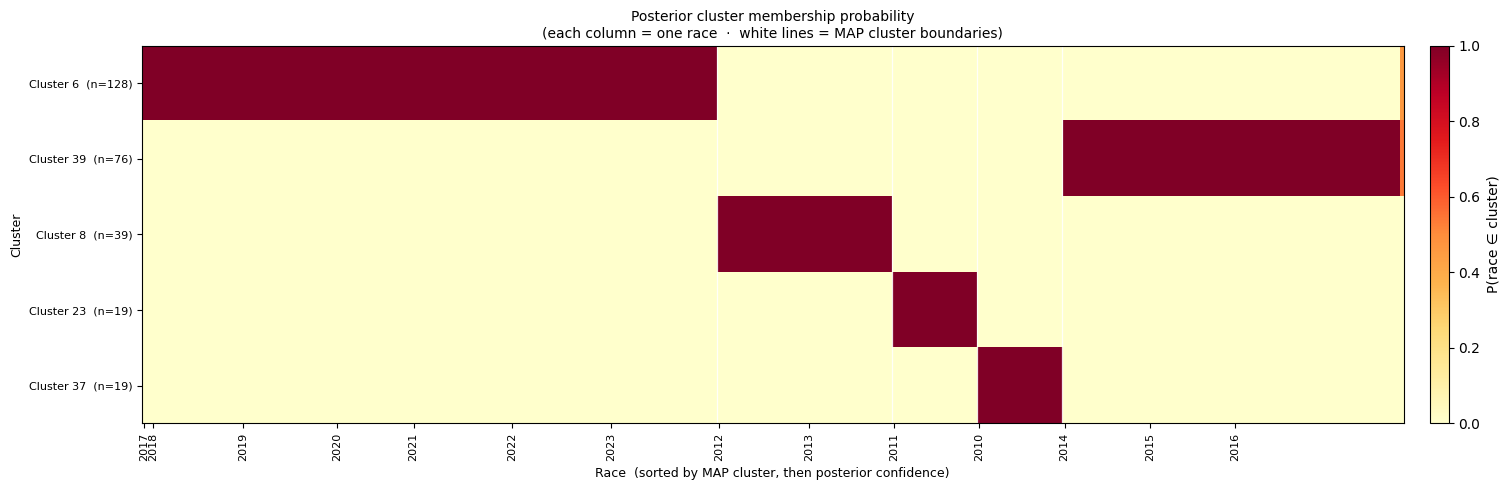

In [48]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Posterior membership matrix ───────────────────────────────────────────────
# membership[i, c] = fraction of post-burn-in samples where race i was in cluster c
z_arr   = np.array(samples_partial.z_samples, dtype=np.intp)   # (T, N)
T_samp  = z_arr.shape[0]
N_races = len(race_labels_partial)

membership = np.zeros((N_races, C_partial), dtype=np.float32)
for t in range(T_samp):
    membership[np.arange(N_races), z_arr[t]] += 1
membership /= T_samp

# ── Sort assessors by MAP cluster, then by posterior confidence desc ──────────
z_map_arr  = np.array(map_result["z"], dtype=int)
confidence = membership[np.arange(N_races), z_map_arr]

sort_ord   = np.lexsort((-confidence, z_map_arr))   # primary: cluster, secondary: -confidence
boundaries = np.where(np.diff(z_map_arr[sort_ord]))[0]

# ── Sort clusters rows: by cluster size (most races first) ───────────────────
cluster_sizes = np.array([(z_map_arr == c).sum() for c in range(C_partial)])
active_clusters = [c for c in np.argsort(-cluster_sizes) if cluster_sizes[c] > 0]
row_order       = active_clusters   # only active clusters

mem_display = membership[sort_ord][:, row_order]   # (N, C_displayed)

# ── Season tick marks along x-axis ───────────────────────────────────────────
season_vec  = np.array([int(lbl.split()[0]) for lbl in race_labels_partial])
season_x    = {}
for i_sorted, i_orig in enumerate(sort_ord):
    s = season_vec[i_orig]
    if s not in season_x:
        season_x[s] = i_sorted

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, N_races * 0.04 + 4), max(5, len(active_clusters) * 0.45 + 2)))

im = ax.imshow(
    mem_display.T, vmin=0, vmax=1, cmap="YlOrRd",
    aspect="auto", interpolation="nearest",
)

# MAP cluster boundary lines (vertical)
for b in boundaries:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)

# Cluster labels on y-axis
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(
    [f"Cluster {c}  (n={cluster_sizes[c]})" for c in row_order],
    fontsize=8,
)

# Season ticks on x-axis
sorted_seasons = sorted(season_x.keys())
ax.set_xticks([season_x[s] for s in sorted_seasons])
ax.set_xticklabels(sorted_seasons, rotation=90, fontsize=8)

ax.set_xlabel("Race  (sorted by MAP cluster, then posterior confidence)", fontsize=9)
ax.set_ylabel("Cluster", fontsize=9)
ax.set_title(
    "Posterior cluster membership probability\n"
    "(each column = one race  ·  white lines = MAP cluster boundaries)",
    fontsize=10,
)
plt.colorbar(im, ax=ax, label="P(race ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()


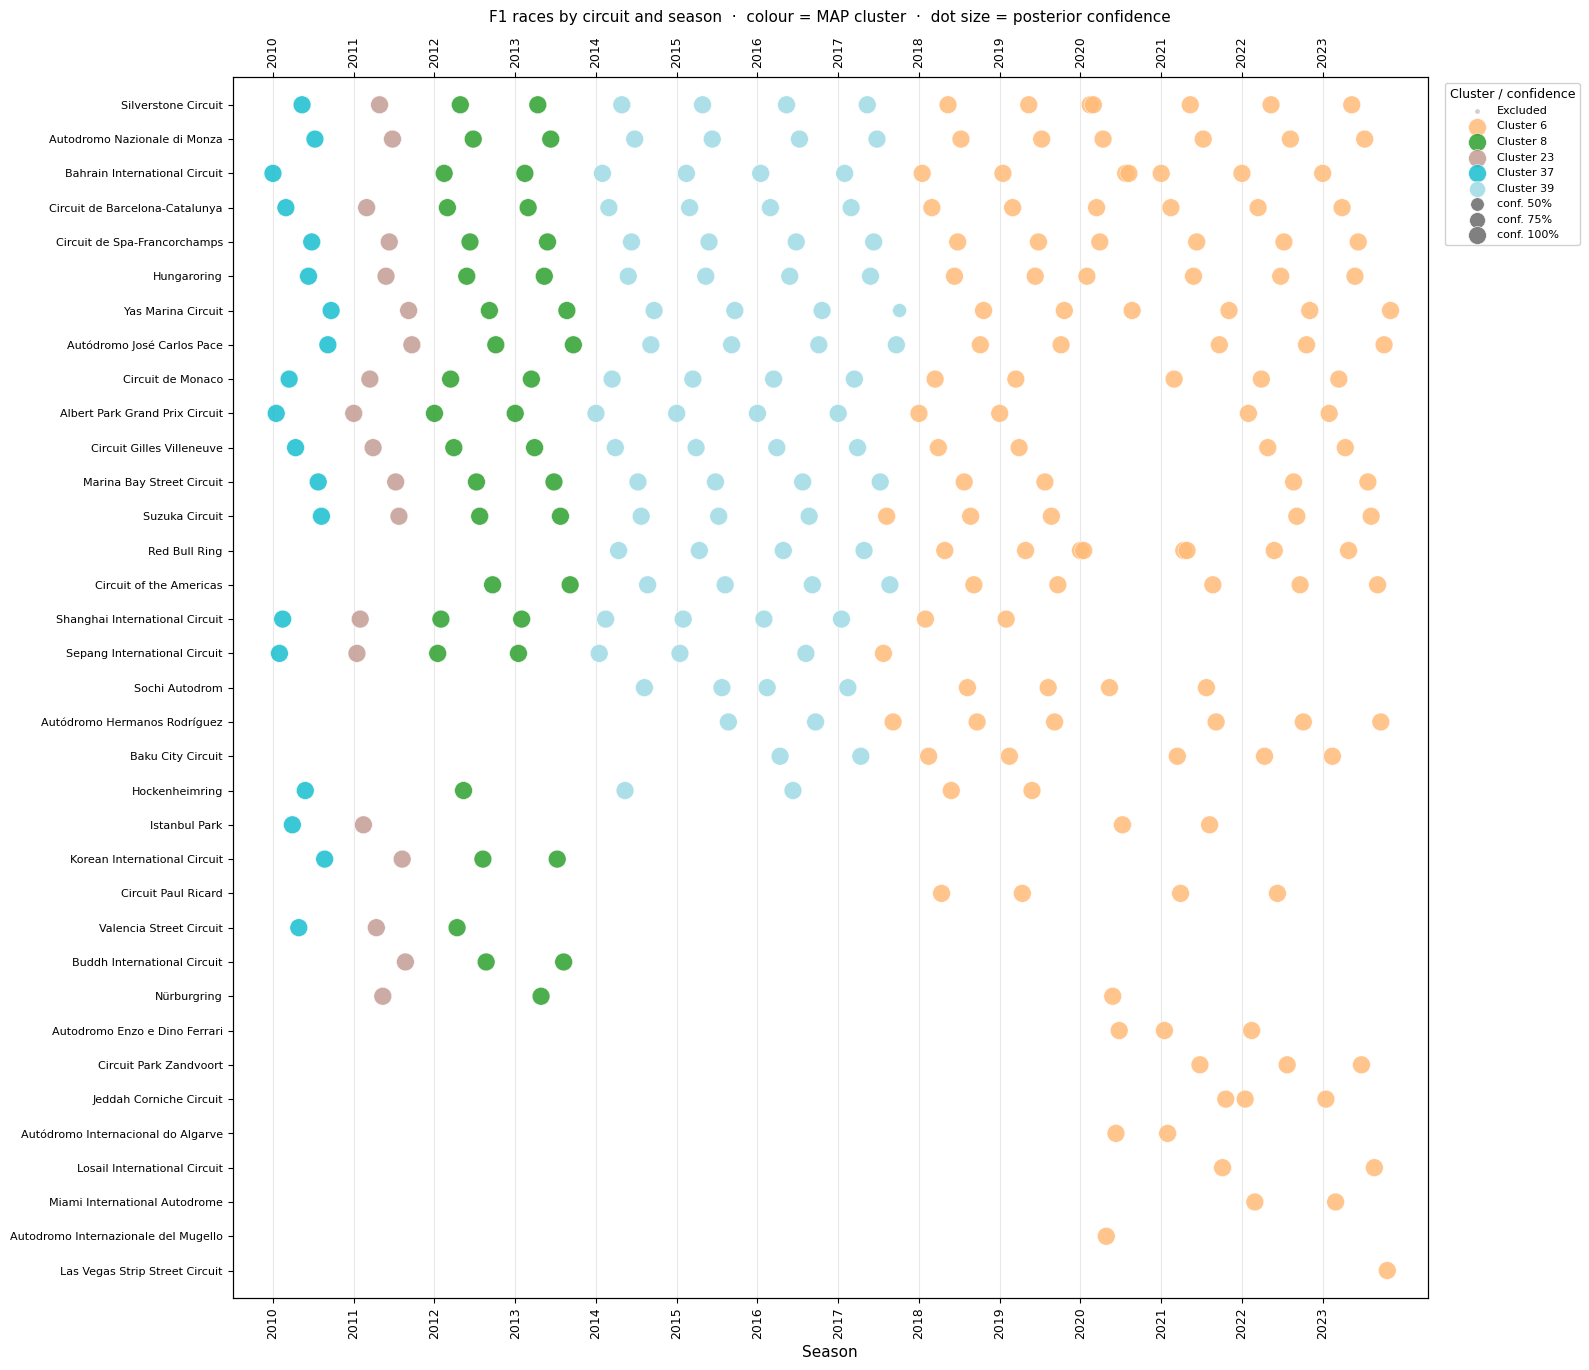

In [49]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── MAP cluster assignments and posterior confidence ──────────────────────────
z_map = map_result["z"]

T = len(samples_partial.z_samples)
N = len(race_labels_partial)
counts_ = [[0] * C_partial for _ in range(N)]
for z_ in samples_partial.z_samples:
    for i, c_ in enumerate(z_):
        counts_[i][c_] += 1
p_ic = [[counts_[i][c_] / T for c_ in range(C_partial)] for i in range(N)]
confidence = [p_ic[i][z_map[i]] for i in range(N)]

# ── Build full race catalogue ─────────────────────────────────────────────────
all_races2 = (
    rankings_full[["season", "round", "race_name", "circuit"]]
    .drop_duplicates()
    .copy()
)
all_races2["race_label"] = (
    all_races2["season"].astype(str)
    + " R" + all_races2["round"].astype(str).str.zfill(2)
    + " " + all_races2["race_name"]
)

subset_map_df = pd.DataFrame({
    "race_label": race_labels_partial,
    "cluster":    z_map,
    "confidence": confidence,
})
all_races2 = all_races2.merge(subset_map_df, on="race_label", how="left")
all_races2["in_subset"] = all_races2["cluster"].notna()

# ── Sort circuits by total appearances, then first season ─────────────────────
circuit_order2 = (
    all_races2.groupby("circuit")
    .agg(total=("season", "count"), first=("season", "min"))
    .sort_values(["total", "first"], ascending=[False, True])
    .index.tolist()
)
all_races2["circuit_rank"] = all_races2["circuit"].map(
    {c: i for i, c in enumerate(circuit_order2)}
)

n_circuits2 = len(circuit_order2)
seasons2    = sorted(all_races2["season"].unique())
cmap_cl2    = plt.get_cmap("tab20", C_partial)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(16, len(seasons2) * 0.8), 4 + n_circuits2 * 0.28))

# Season grid (subtle)
for s2 in seasons2:
    ax.axvline(s2, color="#e8e8e8", linewidth=0.8, zorder=1)

# Excluded races (grey, small)
excl2 = all_races2[~all_races2["in_subset"]]
ax.scatter(
    excl2["season"] + (excl2["round"] - 1) / 25,
    excl2["circuit_rank"],
    color="#d0d0d0", s=12, zorder=2, label="Excluded", linewidths=0,
)

# Included races: colour = cluster, size ∝ posterior confidence
incl2 = all_races2[all_races2["in_subset"]].copy()
incl2["cluster"] = incl2["cluster"].astype(int)
for cl2 in sorted(incl2["cluster"].unique()):
    m2  = incl2["cluster"] == cl2
    sz  = incl2.loc[m2, "confidence"] * 140 + 25   # 25 … 165
    ax.scatter(
        incl2.loc[m2, "season"] + (incl2.loc[m2, "round"] - 1) / 25,
        incl2.loc[m2, "circuit_rank"],
        color=cmap_cl2(cl2), s=sz, zorder=3,
        label=f"Cluster {cl2}",
        edgecolors="white", linewidths=0.4,
        alpha=0.85,
    )

# Axes
ax.set_yticks(range(n_circuits2))
ax.set_yticklabels(circuit_order2, fontsize=8)
ax.set_xticks(seasons2)
ax.set_xticklabels(seasons2, rotation=90, fontsize=9)
ax.set_xlabel("Season", fontsize=11)
ax.set_xlim(min(seasons2) - 0.5, max(seasons2) + 1.3)
ax.set_ylim(-0.8, n_circuits2 - 0.2)
ax.invert_yaxis()   # most-frequent circuits at top
ax.set_title(
    "F1 races by circuit and season  ·  colour = MAP cluster  ·  dot size = posterior confidence",
    fontsize=11, pad=10,
)

# Season labels along top
ax2_top = ax.twiny()
ax2_top.set_xlim(ax.get_xlim())
ax2_top.set_xticks(seasons2)
ax2_top.set_xticklabels(seasons2, rotation=90, fontsize=9)

# Cluster legend (compact, outside right)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    bbox_to_anchor=(1.01, 1), loc="upper left",
    fontsize=8, title="Cluster", title_fontsize=9,
    markerscale=1.1, framealpha=0.9,
)

# Confidence size guide
for conf_val, label in [(0.5, "50%"), (0.75, "75%"), (1.0, "100%")]:
    ax.scatter([], [], s=conf_val * 140 + 25, color="grey",
               label=f"conf. {label}", edgecolors="white", linewidths=0.4)
ax.legend(
    *ax.get_legend_handles_labels(),
    bbox_to_anchor=(1.01, 1), loc="upper left",
    fontsize=8, title="Cluster / confidence", title_fontsize=9,
    framealpha=0.9,
)

plt.tight_layout()
plt.show()


### Consensus rankings (excluding empty clusters and trivial rankings)

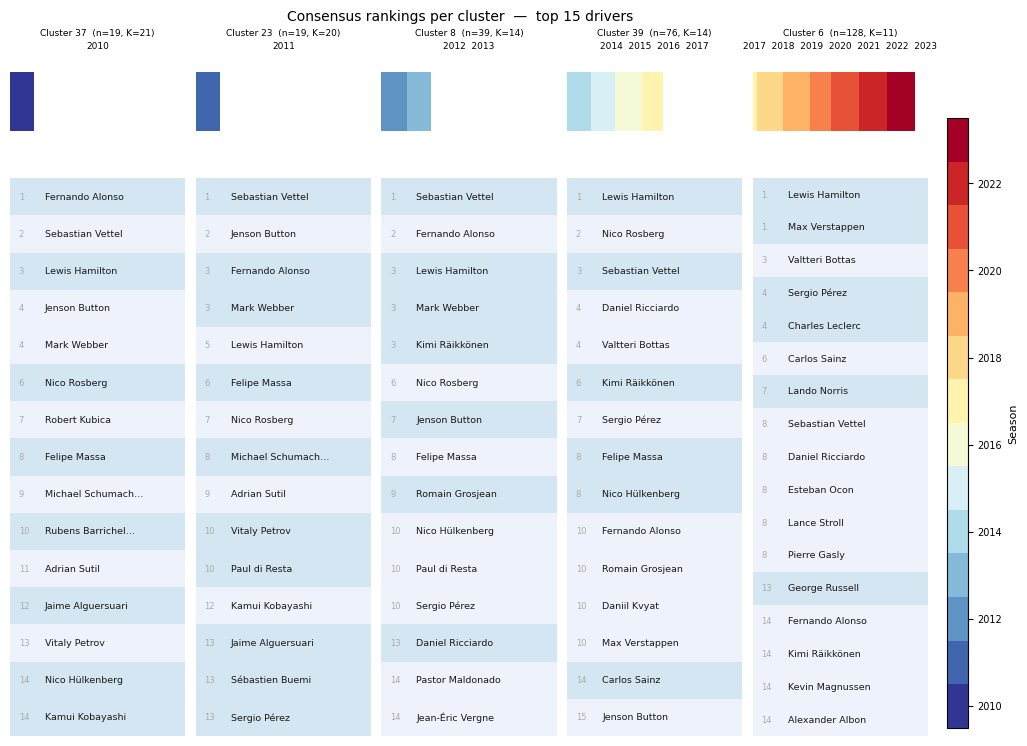

Showing 5 of 40 clusters  (filter: ≥5 races, ≥2 blocks)
Excluded: [0, 1, 2, 3, 4, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38]


In [50]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TOP_K         = 15   # top rank positions shown per cluster
MIN_RACES     = 5    # exclude clusters with fewer races than this
MIN_BLOCKS    = 2    # exclude clusters whose consensus has fewer blocks than this

# ── Driver id → full name lookup ──────────────────────────────────────────────
driver_name_map = (
    rankings_full[["driver_id", "driver_name"]]
    .drop_duplicates("driver_id")
    .set_index("driver_id")["driver_name"]
    .to_dict()
)

# ── Season profile per cluster ────────────────────────────────────────────────
season_vec  = np.array([int(lbl.split()[0]) for lbl in race_labels_partial])
all_seasons = sorted(set(season_vec.tolist()))
n_seasons   = len(all_seasons)
s_to_i      = {s: i for i, s in enumerate(all_seasons)}

cluster_season = np.zeros((C_partial, n_seasons), dtype=int)
for c_i, ssn in zip(z_map, season_vec):
    cluster_season[c_i, s_to_i[ssn]] += 1

# ── Filter clusters ───────────────────────────────────────────────────────────
def _n_blocks(c):
    return len(map_result["clusters"][c]["blocks"])

s_vals = np.array(all_seasons, dtype=float)
mean_s = np.array([
    (cluster_season[c] * s_vals).sum() / max(cluster_season[c].sum(), 1)
    for c in range(C_partial)
])

cluster_order = [
    c for c in np.argsort(mean_s)           # chronological order
    if cluster_season[c].sum() >= MIN_RACES  # not empty / near-empty
    and _n_blocks(c) >= MIN_BLOCKS           # not trivial consensus
]

if not cluster_order:
    print("No clusters passed the filters — lower MIN_RACES or MIN_BLOCKS.")
else:
    # ── Extract top-K drivers from block structure ────────────────────────────
    def top_k_from_blocks(blocks, k):
        rows, pos = [], 1
        for b_idx, block in enumerate(blocks):
            for d_idx in block:
                name = driver_name_map.get(all_drivers[d_idx], all_drivers[d_idx])
                rows.append((pos, b_idx, name))
            pos += len(block)
            if pos > k:
                break
        return [r for r in rows if r[0] <= k]

    # ── Figure ────────────────────────────────────────────────────────────────
    ncols       = len(cluster_order)
    season_cmap = plt.get_cmap("RdYlBu_r", n_seasons)
    block_bg    = ["#eef3fb", "#d4e6f2"]
    max_bar     = cluster_season[cluster_order].sum(axis=1).max() * 1.08

    fig, axes = plt.subplots(
        2, ncols,
        figsize=(ncols * 2.4, 2.8 + TOP_K * 0.37),
        gridspec_kw={"height_ratios": [1, TOP_K * 0.37]},
        squeeze=False,
    )

    for col, c in enumerate(cluster_order):
        blocks   = map_result["clusters"][c]["blocks"]
        top_rows = top_k_from_blocks(blocks, TOP_K)
        counts   = cluster_season[c]
        total    = int(counts.sum())
        n_blk    = len(blocks)

        # ── Season stacked bar ────────────────────────────────────────────────
        ax_s = axes[0, col]
        left = 0
        for s_i, cnt in enumerate(counts):
            if cnt > 0:
                ax_s.barh(0, cnt, left=left, color=season_cmap(s_i), height=0.7, linewidth=0)
                left += cnt
        ax_s.set_xlim(0, max_bar)
        ax_s.set_ylim(-0.6, 0.6)
        ax_s.axis("off")

        active_seasons = sorted(
            [all_seasons[i] for i in range(n_seasons) if counts[i] > 0]
        )
        ssn_str = "  ".join(str(s) for s in active_seasons)
        ax_s.set_title(
            f"Cluster {c}  (n={total}, K={n_blk})\n{ssn_str}",
            fontsize=6.5, pad=2, linespacing=1.5,
        )

        # ── Driver ranking list ───────────────────────────────────────────────
        ax_r = axes[1, col]
        ax_r.set_xlim(0, 1)
        ax_r.set_ylim(0, len(top_rows))
        ax_r.invert_yaxis()
        ax_r.axis("off")

        prev_block, toggle = -1, 0
        for row_i, (rank_pos, b_idx, name) in enumerate(top_rows):
            if b_idx != prev_block:
                toggle, prev_block = 1 - toggle, b_idx
            ax_r.add_patch(plt.Rectangle(
                (0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1,
            ))
            ax_r.text(0.05, row_i + 0.5, str(rank_pos),
                      fontsize=6, va="center", ha="left", color="#aaaaaa", zorder=2)
            short = name if len(name) <= 17 else name[:16] + "…"
            ax_r.text(0.20, row_i + 0.5, short,
                      fontsize=6.8, va="center", ha="left", color="#1a1a1a", zorder=2)

    # ── Season colourbar ──────────────────────────────────────────────────────
    fig.subplots_adjust(hspace=0.08, wspace=0.06, right=0.89, top=0.93)
    cax = fig.add_axes([0.906, 0.12, 0.017, 0.73])
    sm  = plt.cm.ScalarMappable(
        cmap=season_cmap,
        norm=plt.Normalize(vmin=all_seasons[0] - 0.5, vmax=all_seasons[-1] + 0.5),
    )
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_ticks(all_seasons[::2])
    cb.ax.tick_params(labelsize=7)
    cb.set_label("Season", fontsize=8)

    fig.suptitle(
        f"Consensus rankings per cluster  —  top {TOP_K} drivers",
        fontsize=10, y=0.98,
    )
    plt.show()

    print(
        f"Showing {ncols} of {C_partial} clusters  "
        f"(filter: ≥{MIN_RACES} races, ≥{MIN_BLOCKS} blocks)\n"
        f"Excluded: {[c for c in range(C_partial) if c not in cluster_order]}"
    )


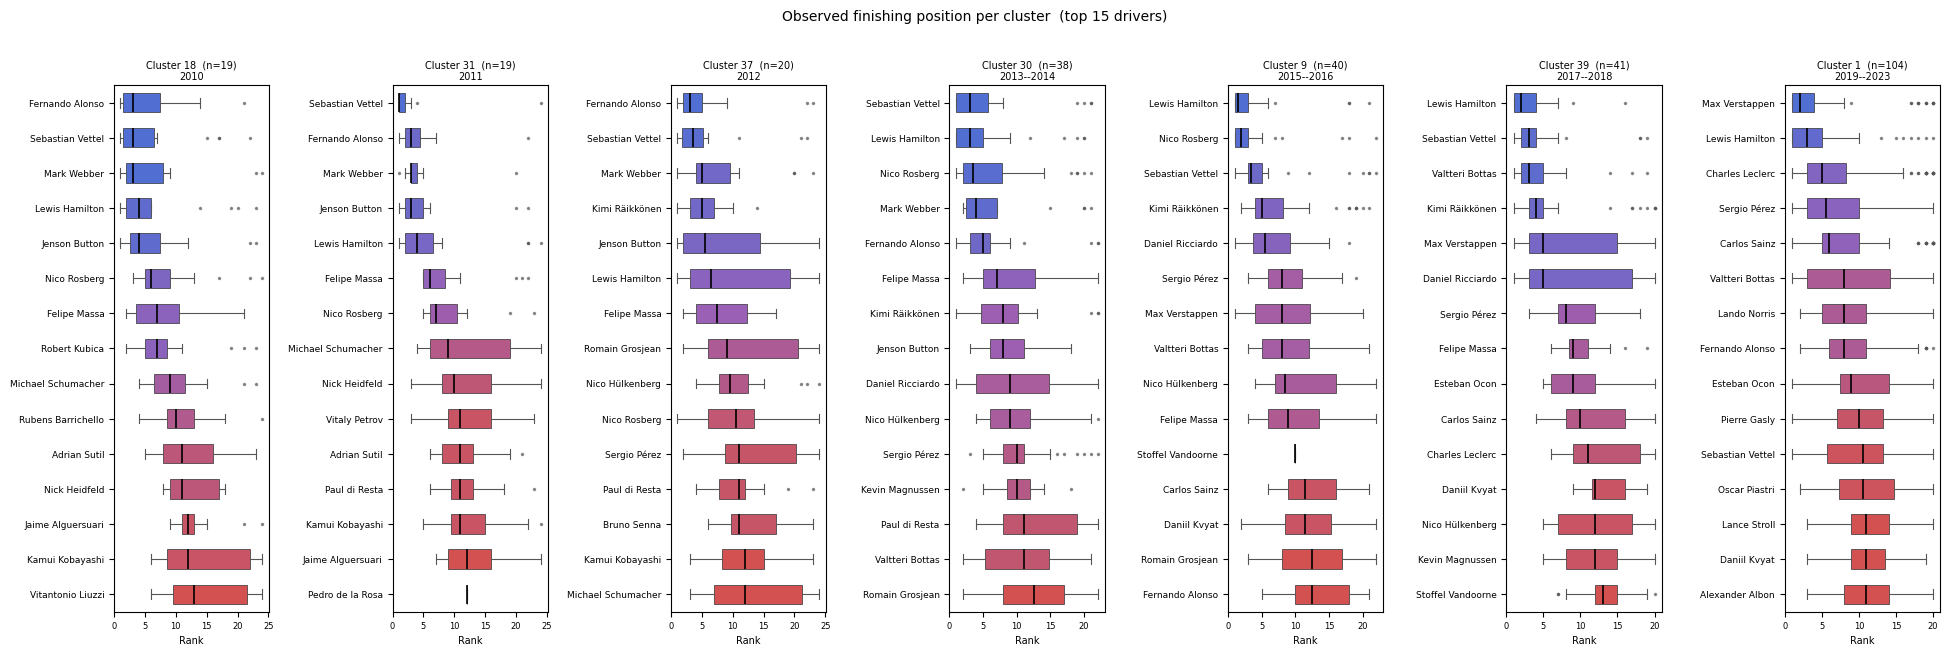

In [46]:
# ── Observed rank distributions per cluster (box plots) ───────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

TOP_K_AVG = 15  # show this many top drivers per cluster

# For each race, build driver_idx → finishing rank (1-indexed)
race_ranks = []
for rl in partial_rankings:
    d = {}
    for rank_0, d_idx in enumerate(rl):
        d[d_idx] = rank_0 + 1  # 1-indexed rank
    race_ranks.append(d)

ncols_avg = len(cluster_order)

# Blue → purple → red colormap (matching reference style)
rank_cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_purple_red", ["#3355cc", "#8844aa", "#cc3333"]
)

fig_avg, axes_avg = plt.subplots(
    1, ncols_avg,
    figsize=(ncols_avg * 2.8, TOP_K_AVG * 0.35 + 1.2),
    squeeze=False,
)

for col, c in enumerate(cluster_order):
    cl_race_idxs = [i for i, z in enumerate(z_map) if z == c]

    driver_ranks = defaultdict(list)
    for ri in cl_race_idxs:
        for d_idx, rank in race_ranks[ri].items():
            driver_ranks[d_idx].append(rank)

    # Compute median for sorting and colouring
    stats = []
    for d_idx, ranks in driver_ranks.items():
        arr = np.array(ranks)
        stats.append({
            "d_idx": d_idx,
            "name": driver_name_map.get(all_drivers[d_idx], all_drivers[d_idx]),
            "median": np.median(arr),
            "mean": arr.mean(),
            "ranks": ranks,
        })

    stats.sort(key=lambda x: x["median"])
    top = stats[:TOP_K_AVG]

    ax = axes_avg[0, col]
    names = [s["name"] if len(s["name"]) <= 18 else s["name"][:17] + "\u2026" for s in top]
    medians = [s["median"] for s in top]
    rank_data = [s["ranks"] for s in top]

    # Per-panel normalisation
    rank_norm = mcolors.Normalize(vmin=min(medians), vmax=max(medians))
    box_colors = [rank_cmap(rank_norm(m)) for m in medians]

    bp = ax.boxplot(
        rank_data, vert=False, patch_artist=True,
        widths=0.55,
        flierprops=dict(marker=".", markersize=3, markerfacecolor="#555555",
                        markeredgecolor="#555555", alpha=0.6),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="#555555", linewidth=0.8),
        capprops=dict(color="#555555", linewidth=0.8),
    )
    for patch, fc in zip(bp["boxes"], box_colors):
        patch.set_facecolor(fc)
        patch.set_edgecolor("#333333")
        patch.set_linewidth(0.6)
        patch.set_alpha(0.85)

    ax.set_yticks(range(1, len(top) + 1))
    ax.set_yticklabels(names, fontsize=6.5)
    ax.invert_yaxis()
    ax.set_xlabel("Rank", fontsize=7)

    counts = cluster_season[c]
    total  = int(counts.sum())
    cl_seasons = sorted([all_seasons[i] for i in range(n_seasons) if counts[i] > 0])
    ssn_str = f"{min(cl_seasons)}" + (f"--{max(cl_seasons)}" if len(cl_seasons) > 1 else "")
    ax.set_title(f"Cluster {c}  (n={total})\n{ssn_str}", fontsize=7, pad=4)
    ax.tick_params(axis="x", labelsize=6)
    ax.set_xlim(0, None)

fig_avg.suptitle(
    f"Observed finishing position per cluster  (top {TOP_K_AVG} drivers)",
    fontsize=10, y=1.01,
)
fig_avg.tight_layout()
plt.show()

 Cl  Races  Blocks  Active  Last blk  Inact   %Inact  Seasons
------------------------------------------------------------------------------------------
 18     19      12      27        49     48    98.0%  2010
 31     19      13      28        50     48    96.0%  2011
 37     20       2      25        53     52    98.1%  2012
 30     38       7      29        51     48    94.1%  2013--2014
  9     40      15      28        50     49    98.0%  2015--2016
 39     41      14      27        51     49    96.1%  2017--2018
  1    104      12      33        53     44    83.0%  2019--2023


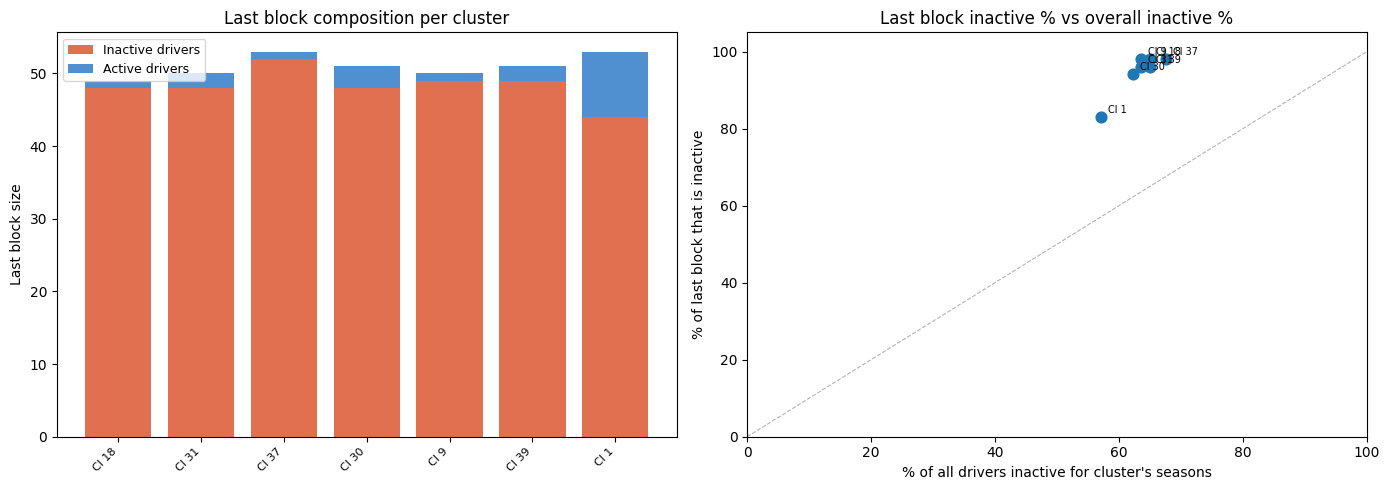


Detailed block profile -- Cluster 37 (seasons 2012--2012):
Block   Rank   Size  Active  Inactive   %Inact
    0      1     24      24         0     0.0%
    1     25     53       1        52    98.1%


In [38]:
# ── Investigate large bottom blocks: are they inactive drivers? ───────────────
import numpy as np
import matplotlib.pyplot as plt

z_map = map_result["z"]
season_vec = np.array([int(lbl.split()[0]) for lbl in race_labels_partial])

# Active drivers per season from raw data
drivers_per_season = rankings_full.groupby("season")["driver_id"].apply(set).to_dict()

# For each cluster: what fraction of the last block is inactive?
summary_rows = []
for c in cluster_order:
    blocks = map_result["clusters"][c]["blocks"]
    cluster_races = [i for i, z in enumerate(z_map) if z == c]
    cluster_seasons = sorted(set(season_vec[i] for i in cluster_races))

    active_ids = set()
    for s in cluster_seasons:
        active_ids |= drivers_per_season.get(s, set())

    # Last block stats
    last_blk = blocks[-1]
    n_inact_last = sum(1 for d in last_blk if all_drivers[d] not in active_ids)

    summary_rows.append({
        "cluster": c,
        "n_races": len(cluster_races),
        "seasons": cluster_seasons,
        "n_blocks": len(blocks),
        "n_active_drivers": len(active_ids),
        "last_block_size": len(last_blk),
        "last_block_inactive": n_inact_last,
        "last_block_pct_inactive": n_inact_last / len(last_blk) * 100,
        "total_inactive": sum(1 for b in blocks for d in b if all_drivers[d] not in active_ids),
    })

# ── Print summary table ──────────────────────────────────────────────────────
print(f"{'Cl':>3}  {'Races':>5}  {'Blocks':>6}  {'Active':>6}  "
      f"{'Last blk':>8}  {'Inact':>5}  {'%Inact':>7}  Seasons")
print("-" * 90)
for r in summary_rows:
    ssn = f"{min(r['seasons'])}--{max(r['seasons'])}" if len(r['seasons']) > 1 else str(r['seasons'][0])
    print(f"{r['cluster']:>3}  {r['n_races']:>5}  {r['n_blocks']:>6}  {r['n_active_drivers']:>6}  "
          f"{r['last_block_size']:>8}  {r['last_block_inactive']:>5}  "
          f"{r['last_block_pct_inactive']:>6.1f}%  {ssn}")

# ── Visualisation: per-cluster last block composition ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(summary_rows))
labels = [f"Cl {r['cluster']}" for r in summary_rows]

# Left: last block size, stacked by active/inactive
inactive_vals = [r["last_block_inactive"] for r in summary_rows]
active_vals   = [r["last_block_size"] - r["last_block_inactive"] for r in summary_rows]
ax1.bar(x, inactive_vals, label="Inactive drivers", color="#e07050")
ax1.bar(x, active_vals, bottom=inactive_vals, label="Active drivers", color="#5090d0")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Last block size")
ax1.set_title("Last block composition per cluster")
ax1.legend(fontsize=9)

# Right: % inactive in last block vs total inactive in consensus
pct_last = [r["last_block_pct_inactive"] for r in summary_rows]
n_total = len(all_drivers)
pct_total = [r["total_inactive"] / n_total * 100 for r in summary_rows]
ax2.scatter(pct_total, pct_last, s=60, zorder=3)
for i, r in enumerate(summary_rows):
    ax2.annotate(f"Cl {r['cluster']}", (pct_total[i], pct_last[i]),
                 fontsize=7, textcoords="offset points", xytext=(5, 3))
ax2.plot([0, 100], [0, 100], "k--", alpha=0.3, lw=0.8)
ax2.set_xlabel("% of all drivers inactive for cluster's seasons")
ax2.set_ylabel("% of last block that is inactive")
ax2.set_title("Last block inactive % vs overall inactive %")
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 105)

fig.tight_layout()
plt.show()

# ── Per-block profile for the cluster with biggest last block ─────────────────
biggest = max(summary_rows, key=lambda r: r["last_block_size"])
c_big = biggest["cluster"]
blocks_big = map_result["clusters"][c_big]["blocks"]
cl_seasons = biggest["seasons"]
active_ids_big = set()
for s in cl_seasons:
    active_ids_big |= drivers_per_season.get(s, set())

print(f"\nDetailed block profile -- Cluster {c_big} "
      f"(seasons {min(cl_seasons)}--{max(cl_seasons)}):")
print(f"{'Block':>5}  {'Rank':>5}  {'Size':>5}  {'Active':>6}  {'Inactive':>8}  {'%Inact':>7}")
pos = 1
for b_idx, block in enumerate(blocks_big):
    n_a = sum(1 for d in block if all_drivers[d] in active_ids_big)
    n_i = len(block) - n_a
    pct = n_i / len(block) * 100 if block else 0
    if b_idx < 5 or b_idx >= len(blocks_big) - 3:
        print(f"{b_idx:>5}  {pos:>5}  {len(block):>5}  {n_a:>6}  {n_i:>8}  {pct:>6.1f}%")
    elif b_idx == 5:
        print(f"  ... ({len(blocks_big) - 8} blocks omitted)")
    pos += len(block)